# Dự đoán giá xe ô tô

## 1. EDA 


In [249]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [250]:
df_car = pd.read_csv('data/df_car.csv')
df_car = df_car.drop(columns = ['ID'])

In [252]:
# Xem du lieu
df_car.head(10)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,39493,891,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931 km,4.0,Automatic,Front,04-May,Left wheel,White,4
6,1803,761,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909 km,4.0,Automatic,Front,04-May,Left wheel,White,12
7,549,751,HYUNDAI,Sonata,2013,Sedan,Yes,Petrol,2.4,216118 km,4.0,Automatic,Front,04-May,Left wheel,Grey,12
8,1098,394,TOYOTA,Camry,2014,Sedan,Yes,Hybrid,2.5,398069 km,4.0,Automatic,Front,04-May,Left wheel,Black,12
9,26657,-,LEXUS,RX 350,2007,Jeep,Yes,Petrol,3.5,128500 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12


=> Cot Levy co dau '-'


In [253]:
df_car.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             19237 non-null  int64  
 1   Levy              19237 non-null  str    
 2   Manufacturer      19237 non-null  str    
 3   Model             19237 non-null  str    
 4   Prod. year        19237 non-null  int64  
 5   Category          19237 non-null  str    
 6   Leather interior  19237 non-null  str    
 7   Fuel type         19237 non-null  str    
 8   Engine volume     19237 non-null  str    
 9   Mileage           19237 non-null  str    
 10  Cylinders         19237 non-null  float64
 11  Gear box type     19237 non-null  str    
 12  Drive wheels      19237 non-null  str    
 13  Doors             19237 non-null  str    
 14  Wheel             19237 non-null  str    
 15  Color             19237 non-null  str    
 16  Airbags           19237 non-null  int64  
dtypes: f

=> Levy, Mileage, Engine volume chi co so -> co the chuyen ve kieu so

In [254]:
# Chia 2 kieu numerical va catelogical
categorical = df_car.select_dtypes(include=['object'])
numerical = df_car.select_dtypes(include= ['number'])

C:\Users\duong\AppData\Local\Temp\ipykernel_28116\660702582.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df_car.select_dtypes(include=['object'])


### 1. Phân tích biến Numerical


In [255]:
# thong ke
numerical.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,19237.0,18555.927224,190581.269684,1.0,5331.0,13172.0,22075.0,26307500.0
Prod. year,19237.0,2010.912824,5.668673,1939.0,2009.0,2012.0,2015.0,2020.0
Cylinders,19237.0,4.582991,1.199933,1.0,4.0,4.0,4.0,16.0
Airbags,19237.0,6.582627,4.320168,0.0,4.0,6.0,12.0,16.0


In [256]:
# kiem tra missing
df_car.isnull().sum()

Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [257]:
num_cols = df_car.select_dtypes(include='number').columns
cat_col = df_car.select_dtypes(include = 'object').columns

C:\Users\duong\AppData\Local\Temp\ipykernel_28116\1812966086.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df_car.select_dtypes(include = 'object').columns


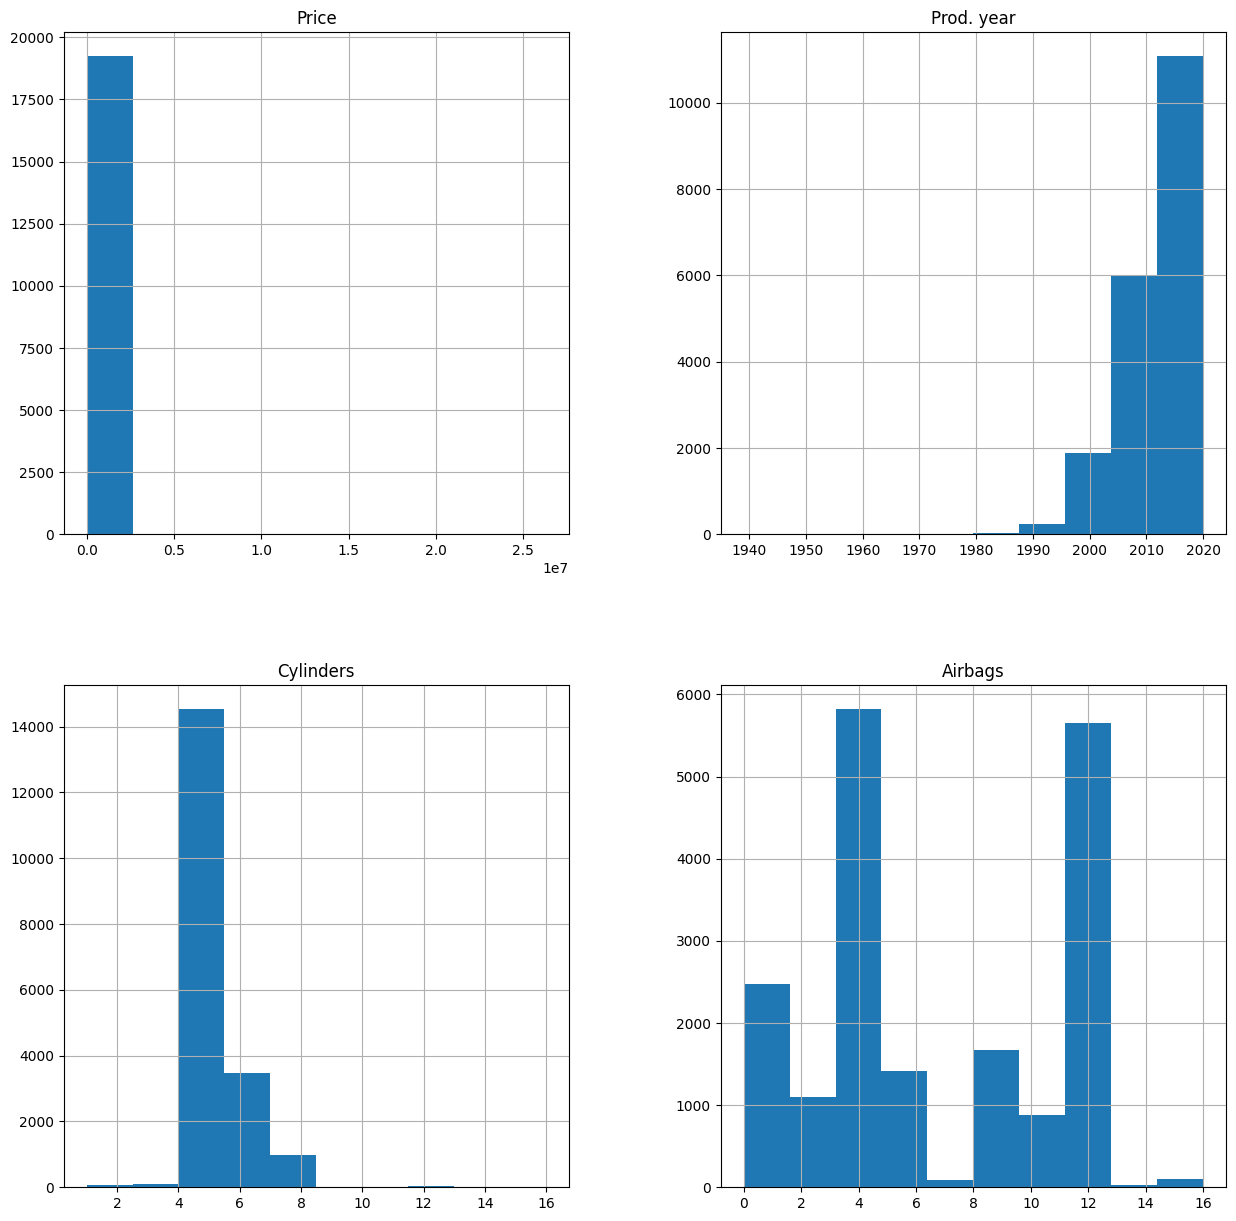

In [258]:
numerical.hist(figsize=(15,15), bins = 10)
plt.show()

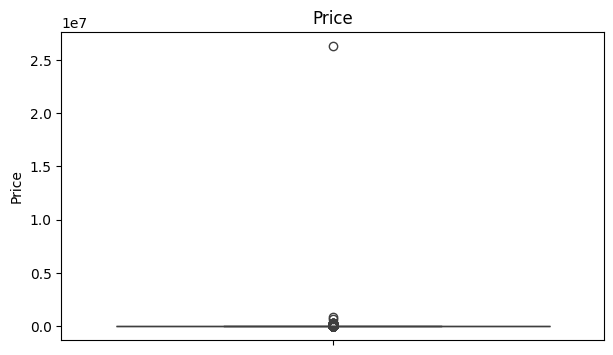

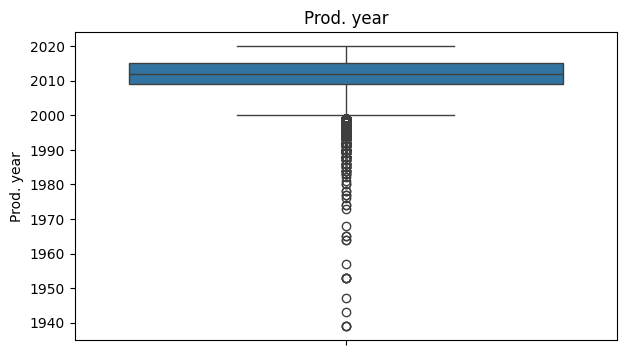

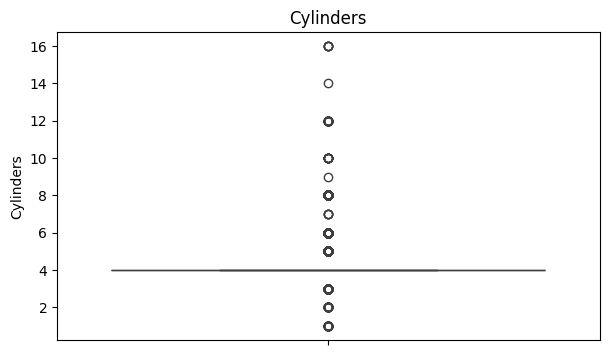

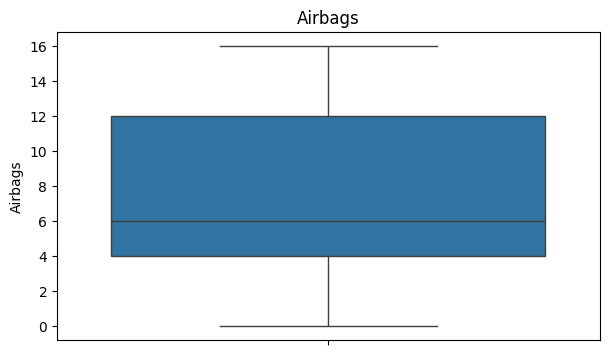

In [259]:
for col in numerical.columns:
    plt.figure(figsize=(7,4))
    sns.boxplot(y=numerical[col])
    plt.title(col)
    plt.show()

In [260]:
# Ma tran tuong quan
corr_matrix = numerical.corr()

corr_matrix

,Price,Prod. year,Cylinders,Airbags
Price,1.000000,0.012982,0.007518,-0.012824
Prod. year,0.012982,1.000000,-0.096797,0.236969
Cylinders,0.007518,-0.096797,1.000000,0.176868
Airbags,-0.012824,0.236969,0.176868,1.000000


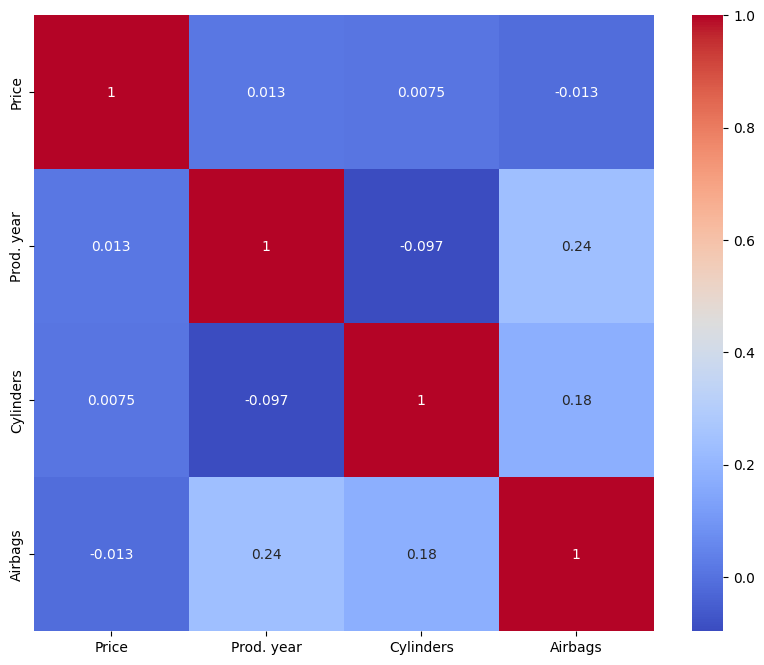

In [261]:
# truc quan moi quan he
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')
plt.show()

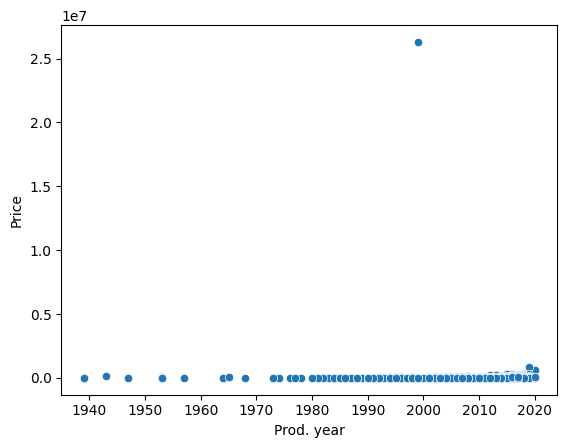

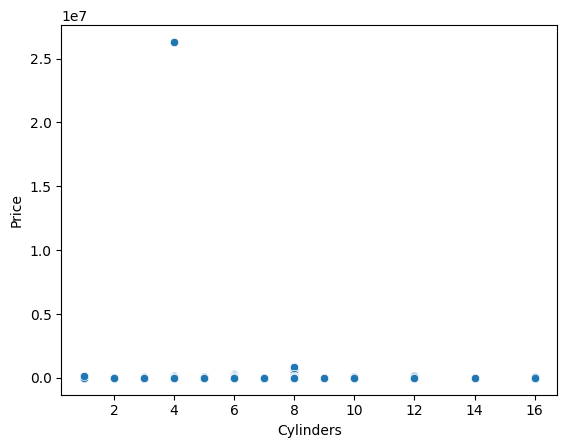

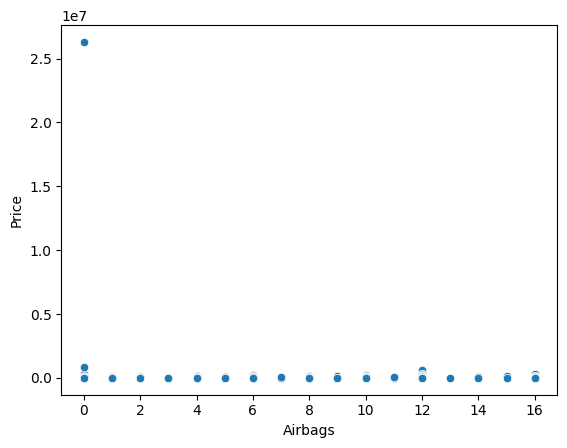

In [262]:
for col in numerical.columns:
    if col != 'Price':
        sns.scatterplot(
            x=col,
            y='Price',
            data=df_car
        )
        plt.show()

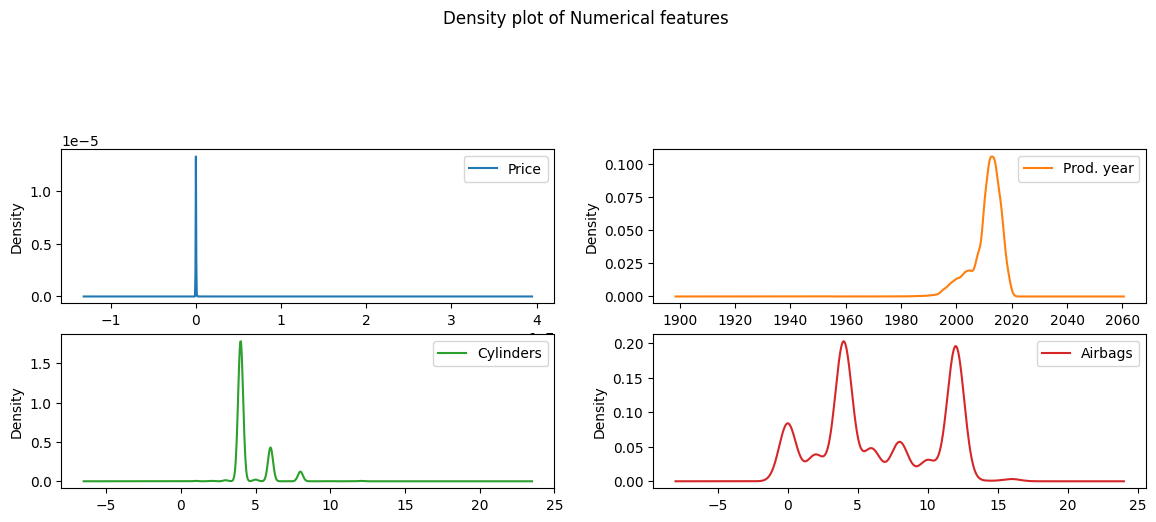

In [263]:
numerical.plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

### 2. Phân tích biến Categorical


In [264]:
# Phan tich bien categorical
categorical.nunique()

Levy                 559
Manufacturer          65
Model               1590
Category              11
Leather interior       2
Fuel type              7
Engine volume        107
Mileage             7687
Gear box type          4
Drive wheels           3
Doors                  3
Wheel                  2
Color                 16
dtype: int64

C:\Users\duong\AppData\Local\Temp\ipykernel_28116\2186672451.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = categorical.select_dtypes(include = 'object').columns


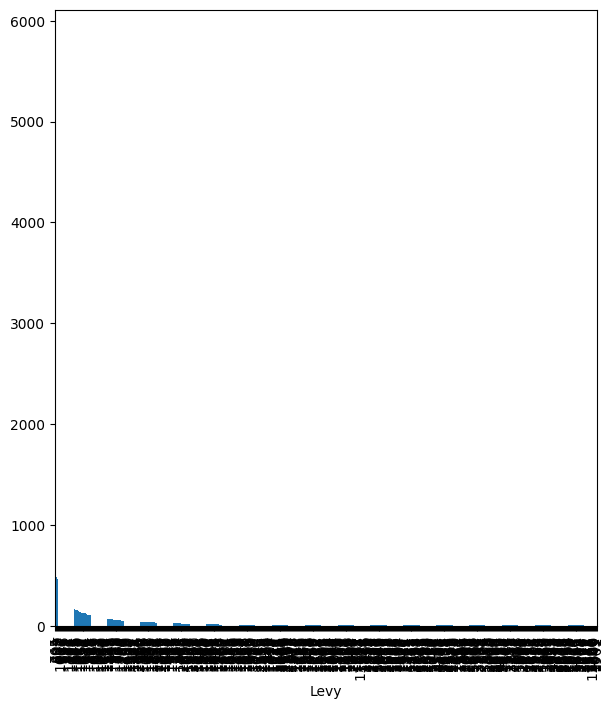

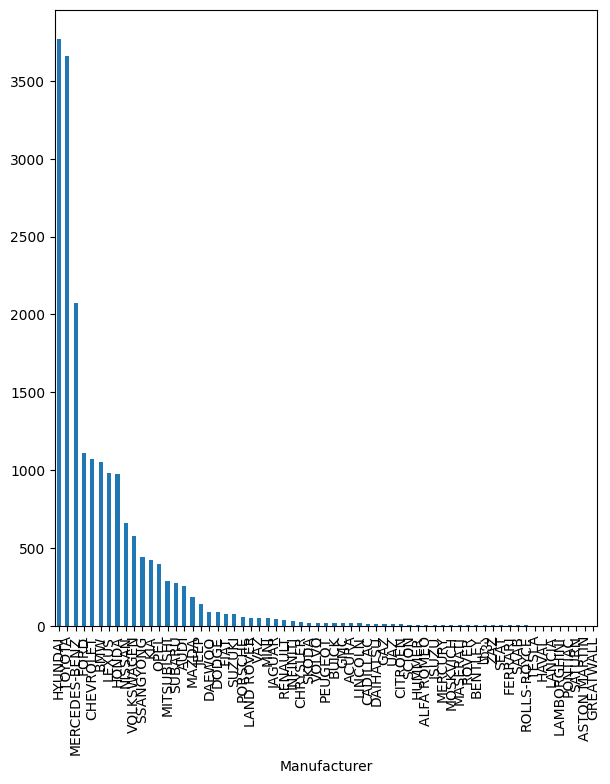

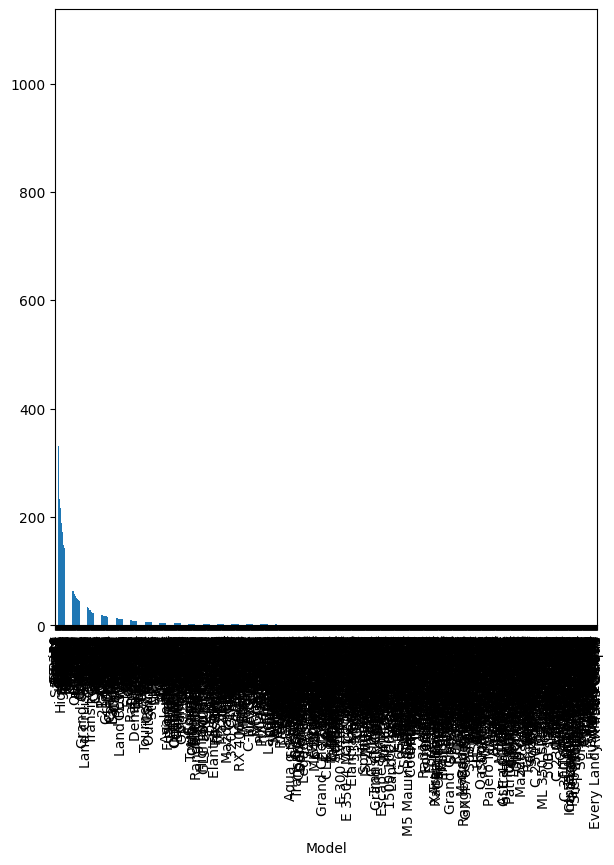

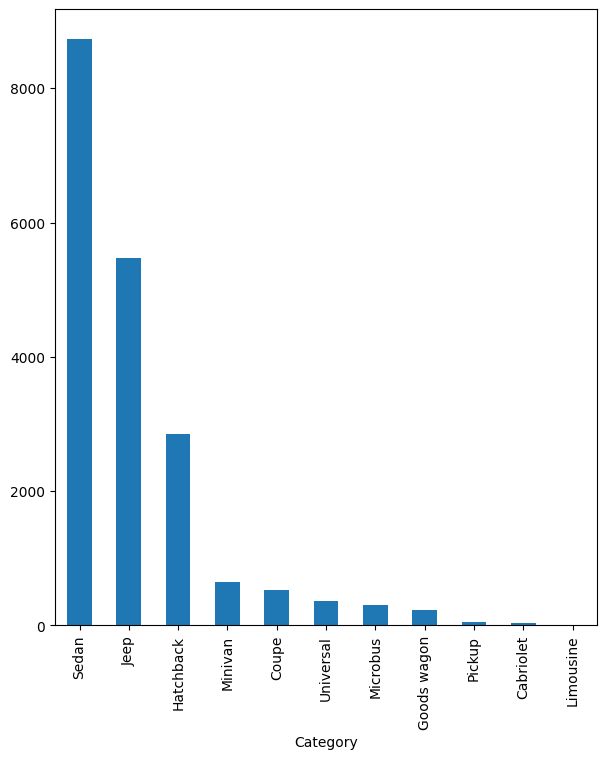

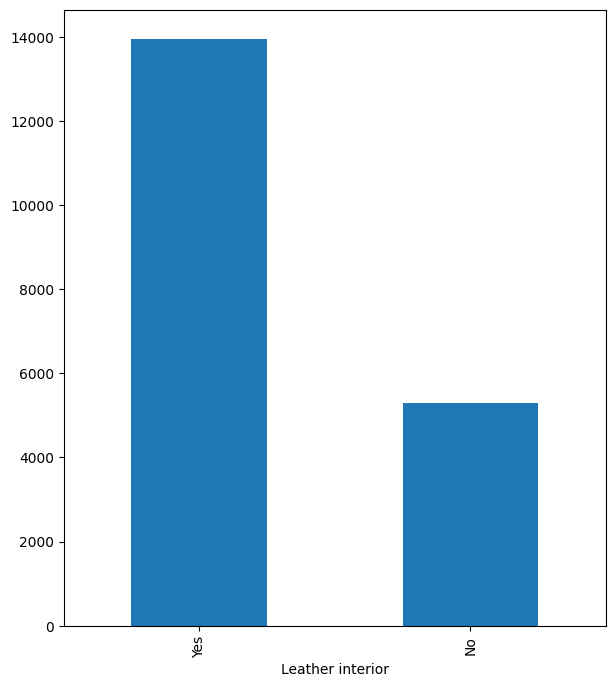

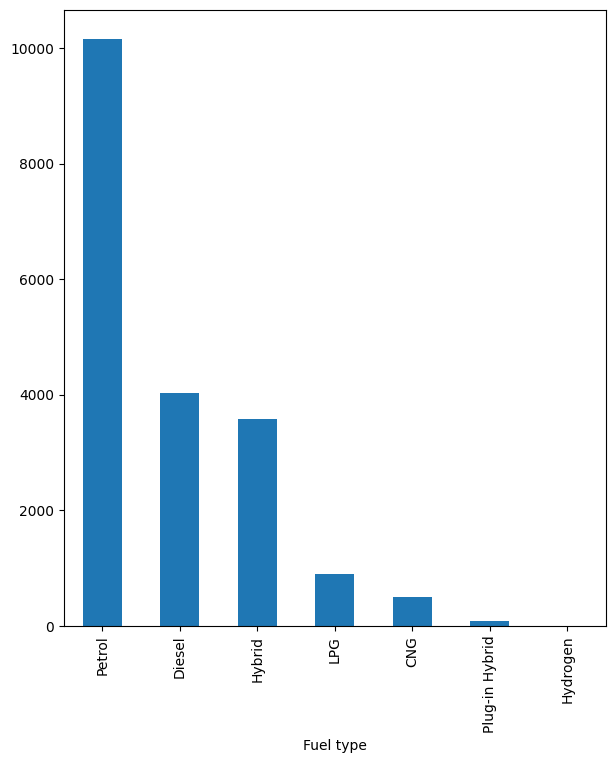

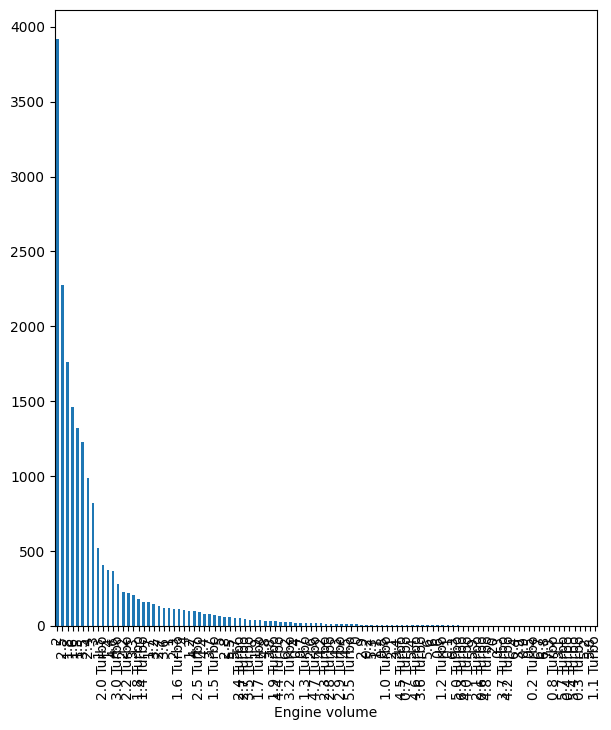

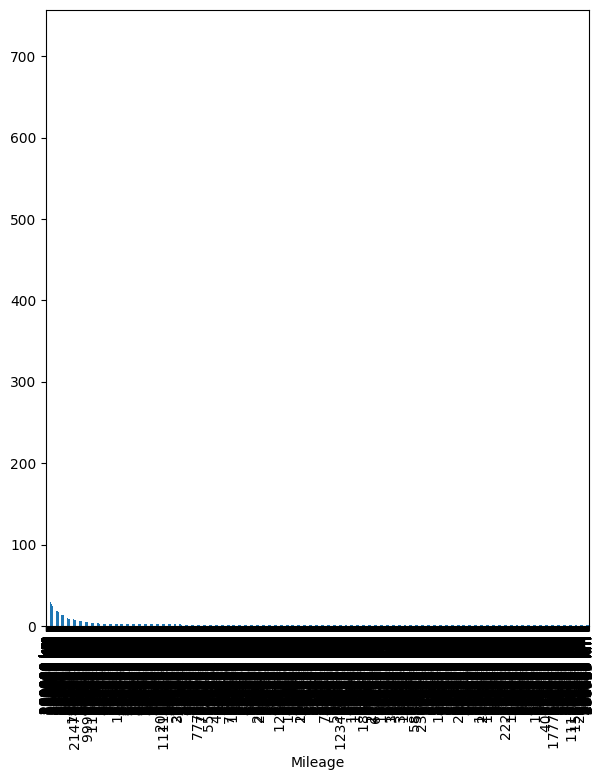

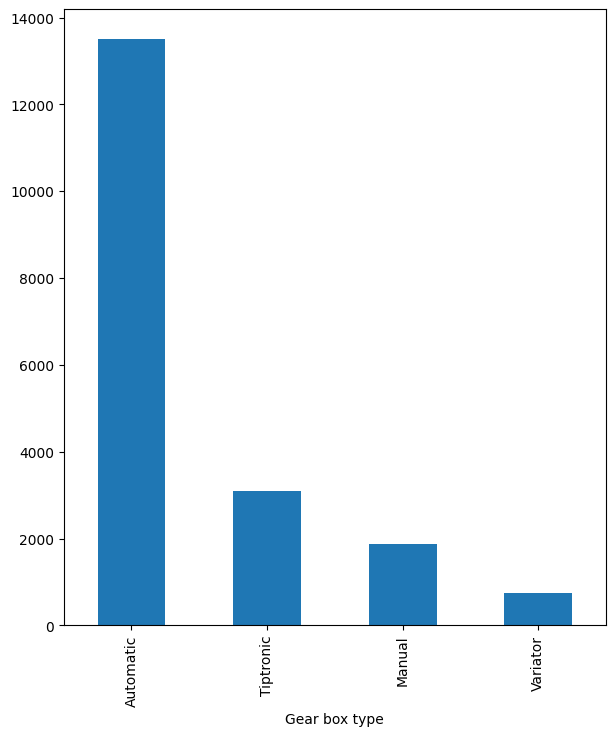

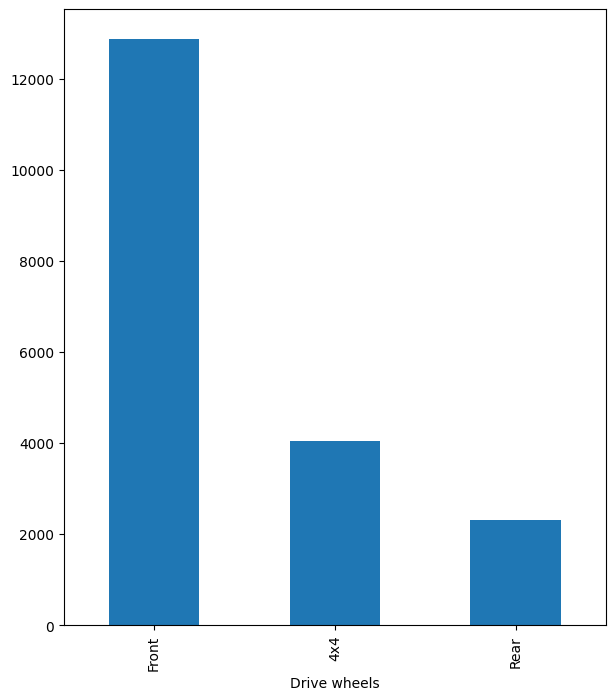

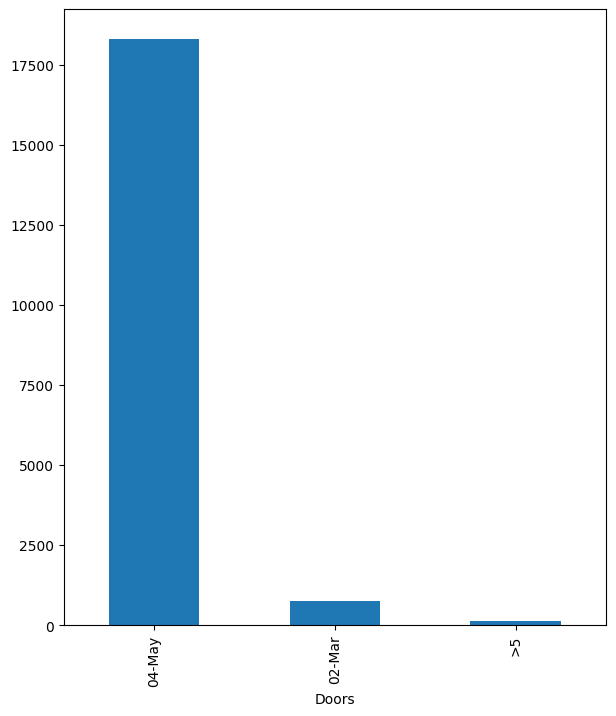

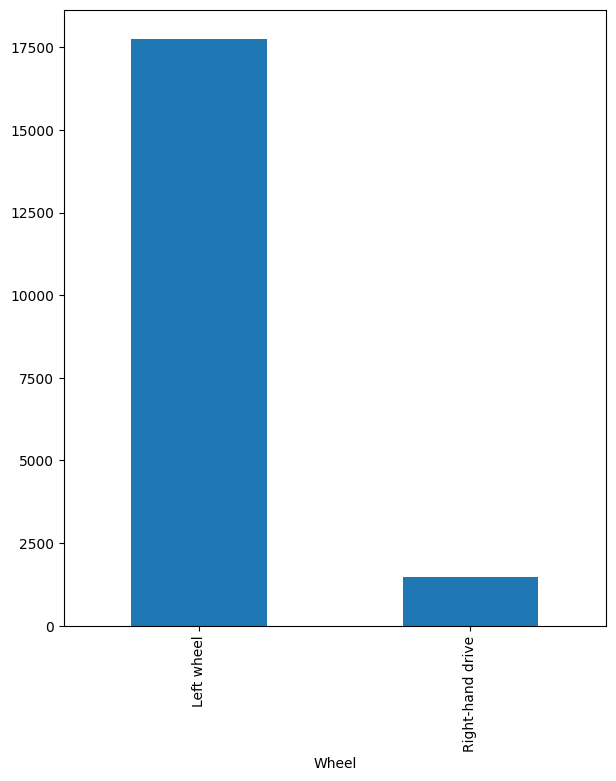

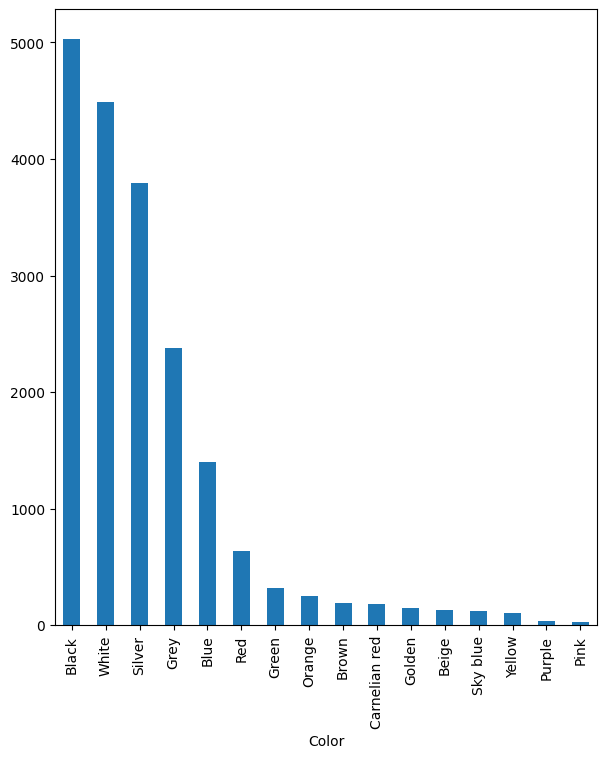

In [265]:
cat_cols = categorical.select_dtypes(include = 'object').columns

for col in cat_cols:
    plt.figure(figsize=(7,8))
    categorical[col].value_counts().plot(kind='bar')
    plt.show()


## 2. Tiền xử Lý

1. Xử lý cột sai kiểu

In [266]:
df_car['Levy'] = df_car['Levy'].replace('-', '0')
df_car['Mileage'] = df_car['Mileage'].str.replace('km', '')
df_car['Engine volume'] = df_car['Engine volume'].str.replace('Turbo', '')

In [267]:
df_car['Levy'] = pd.to_numeric(df_car['Levy'])
df_car['Levy'] = df_car['Levy'].replace(0, df_car['Levy'].mean())

In [268]:
df_car['Engine volume'] = pd.to_numeric(df_car['Engine volume'])
df_car['Mileage'] = pd.to_numeric(df_car['Mileage'])
df_car['Airbags'] = pd.to_numeric(df_car['Airbags'])
df_car['Cylinders'] = pd.to_numeric(df_car['Cylinders'])

In [269]:
df_car.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             19237 non-null  int64  
 1   Levy              19237 non-null  float64
 2   Manufacturer      19237 non-null  str    
 3   Model             19237 non-null  str    
 4   Prod. year        19237 non-null  int64  
 5   Category          19237 non-null  str    
 6   Leather interior  19237 non-null  str    
 7   Fuel type         19237 non-null  str    
 8   Engine volume     19237 non-null  float64
 9   Mileage           19237 non-null  int64  
 10  Cylinders         19237 non-null  float64
 11  Gear box type     19237 non-null  str    
 12  Drive wheels      19237 non-null  str    
 13  Doors             19237 non-null  str    
 14  Wheel             19237 non-null  str    
 15  Color             19237 non-null  str    
 16  Airbags           19237 non-null  int64  
dtypes: f

2. Loại bỏ trùng lặp

In [270]:
# Loai bo trung lap
df_car.drop_duplicates(inplace=True)
print(df_car.shape)

(15725, 17)


3. Xử lý outliers

In [271]:
Q1 = df_car['Price'].quantile(0.25)
Q3 = df_car['Price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
df_car = df_car[(df_car['Price'] >= lower) &(df_car['Price'] <= upper)]

In [272]:
df_car['Price'].skew()

np.float64(0.8103899980495658)

4. Encode và scale

In [273]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Chuan bi du lieu cho mo hinh: dung New Price lam bien muc tieu
model_data = df_car

y = model_data['Price']
X = model_data.drop(columns=['Price'])

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()
# Ma hoa bien phan loai (One-Hot) va chuan hoa bien so (StandardScaler)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Chia train/test (80/20), scaler/encoder chi fit tren tap train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Kich thuoc tap train: {X_train.shape}')
print(f'Kich thuoc tap test: {X_test.shape}')
print(f'So bien phan loai: {len(cat_cols)}, so bien so: {len(num_cols)}')


Kich thuoc tap train: (11814, 16)
Kich thuoc tap test: (2954, 16)
So bien phan loai: 10, so bien so: 6


C:\Users\duong\AppData\Local\Temp\ipykernel_28116\2754866713.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


## 3. Huấn luyện mô hình


In [274]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=12),
    'Random Forest': RandomForestRegressor(
        random_state=42, n_estimators=100, max_depth=15, n_jobs=-1
    ),
    'KNN': KNeighborsRegressor(n_neighbors=7),
    'SVR': SVR(kernel='linear', C=1.0)
}

pipelines = {}
results = []
predictions = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    pipelines[name] = pipe
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'model': name,
        'MAE': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 4)
    })

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df


,model,MAE,MSE,RMSE,R2
0,Random Forest,4107.56,3.843751e+07,6199.80,0.6856
1,KNN,4684.10,4.973318e+07,7052.18,0.5932
2,Decision Tree,4792.89,5.365704e+07,7325.10,0.5611
3,Linear Regression,6313.00,7.049588e+07,8396.18,0.4234
4,SVR,7395.38,1.000848e+08,10004.24,0.1813


## 4. Đánh giá mô hình

Báo cáo MAE, MSE, RMSE, R²; biểu đồ Actual vs Predicted và Residual.


In [275]:
os.makedirs('outputs/figures', exist_ok=True)
results_df.to_csv('outputs/results.csv', index=False)
results_df


,model,MAE,MSE,RMSE,R2
0,Random Forest,4107.56,3.843751e+07,6199.80,0.6856
1,KNN,4684.10,4.973318e+07,7052.18,0.5932
2,Decision Tree,4792.89,5.365704e+07,7325.10,0.5611
3,Linear Regression,6313.00,7.049588e+07,8396.18,0.4234
4,SVR,7395.38,1.000848e+08,10004.24,0.1813


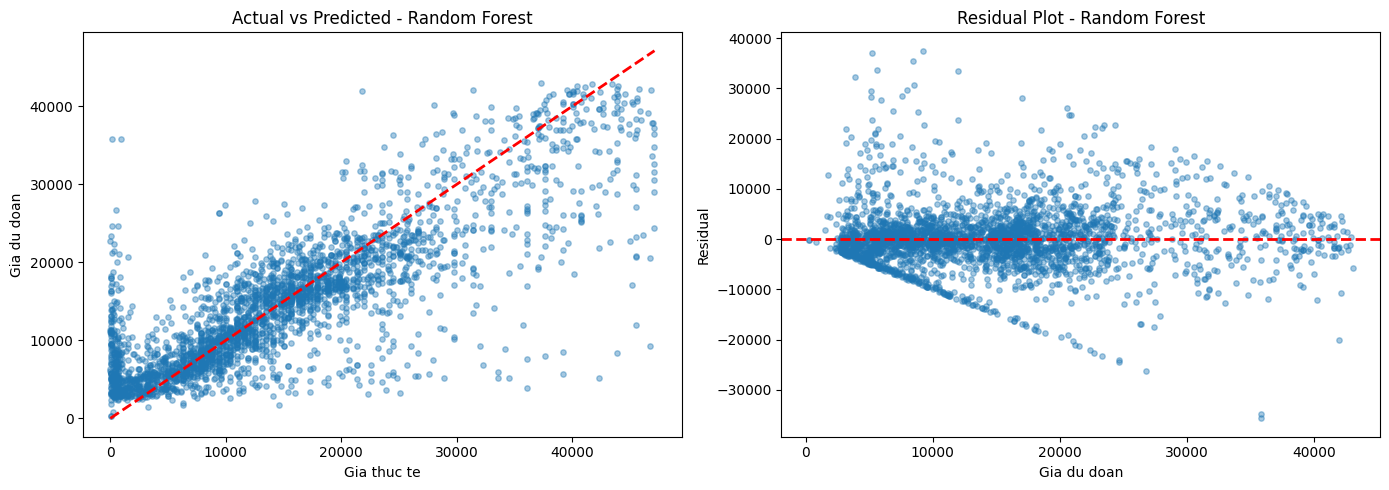

In [276]:
best_model = results_df.iloc[0]['model']
y_pred_best = predictions[best_model]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.4, s=15)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Gia thuc te')
axes[0].set_ylabel('Gia du doan')
axes[0].set_title(f'Actual vs Predicted - {best_model}')

residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.4, s=15)
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Gia du doan')
axes[1].set_ylabel('Residual')
axes[1].set_title(f'Residual Plot - {best_model}')

plt.tight_layout()
plt.savefig('outputs/figures/actual_vs_predicted_residual.png', dpi=120, bbox_inches='tight')
plt.show()


C:\Users\duong\AppData\Local\Temp\ipykernel_28116\2863786440.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='model', y=metric, ax=ax, palette='viridis')
C:\Users\duong\AppData\Local\Temp\ipykernel_28116\2863786440.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='model', y=metric, ax=ax, palette='viridis')
C:\Users\duong\AppData\Local\Temp\ipykernel_28116\2863786440.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='model', y=metric, ax=ax, palette='viridis')


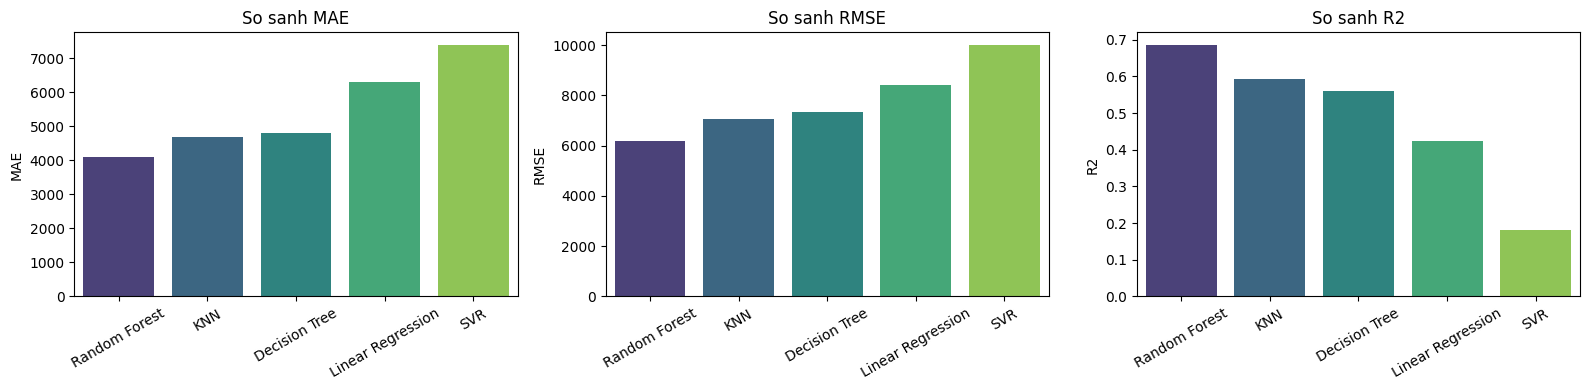

In [277]:
metrics = ['MAE', 'RMSE', 'R2']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric in zip(axes, metrics):
    sns.barplot(data=results_df, x='model', y=metric, ax=ax, palette='viridis')
    ax.set_title(f'So sanh {metric}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outputs/figures/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


C:\Users\duong\AppData\Local\Temp\ipykernel_28116\1588619536.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='Blues_r')


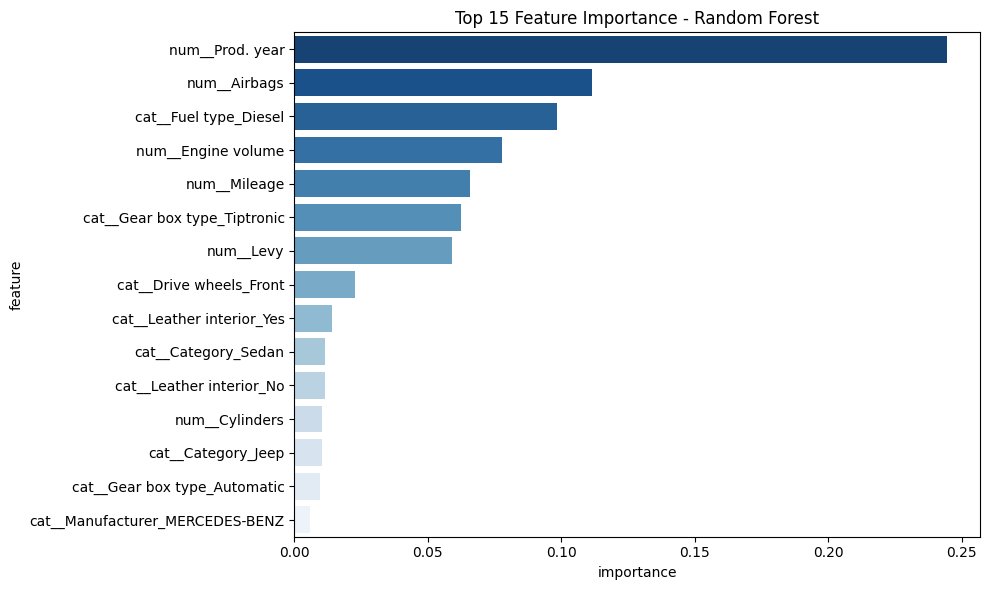

In [278]:
rf_pipe = pipelines['Random Forest']
feature_names = rf_pipe.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipe.named_steps['model'].feature_importances_

importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='Blues_r')
plt.title('Top 15 Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('outputs/figures/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. So sánh và kết luận


### Phân tích và so sánh kết quả

**Mô hình tốt nhất:** Random Forest Regressor (RMSE thấp nhất, R² cao nhất trên tập test).

**Chỉ số lựa chọn:** RMSE và R² — RMSE đo sai số tuyệt đối trên cùng đơn vị với giá xe; R² cho biết mô hình giải thích được bao nhiêu phần biến thiên của giá.

**Vì sao Random Forest tốt hơn:**
- Kết hợp nhiều cây quyết định, giảm overfitting so với Decision Tree đơn lẻ.
- Nắm bắt tốt quan hệ phi tuyến giữa hãng xe, năm sản xuất, số km, loại nhiên liệu và giá.
- Linear Regression và SVR kém hơn vì quan hệ giữa đặc trưng và giá không hoàn toàn tuyến tính.

**Overfitting / Underfitting:**
- Decision Tree có thể overfit nếu `max_depth` quá lớn; đã giới hạn `max_depth=12`.
- Linear Regression underfit (R² thấp) — mô hình quá đơn giản với dữ liệu phức tạp.
- Random Forest cân bằng bias–variance tốt hơn trên tập test.

**Khó khăn gặp phải:**
- Dữ liệu có nhiều biến phân loại (Manufacturer, Model, Color...) → số chiều tăng sau One-Hot Encoding.
- Giá trị thiếu ở `Levy`, outlier ở `Price`, định dạng `Mileage`/`Engine volume` cần làm sạch trước khi huấn luyện.

**Hướng cải thiện:**
- GridSearchCV / RandomizedSearchCV để tinh chỉnh hyperparameter.
- Feature engineering: tuổi xe = năm hiện tại − Prod Year; gom nhóm hãng xe hiếm.
- Thử XGBoost/LightGBM; xử lý outlier bằng log-transform cho `Price`.
- Loại bỏ hoặc gom nhóm các category có tần suất quá thấp.
